# 🔢 Task 10: KNN - Handwritten Digit Classification
**Project:** Optical Character Recognition (OCR) Lite  

## 🎯 Objective
To classify images of handwritten digits (0-9) using the **K-Nearest Neighbors (KNN)** algorithm.
This task demonstrates:
1.  **Distance-based Learning:** How KNN uses mathematical proximity to classify data.
2.  **Hyperparameter Tuning:** Finding the optimal number of neighbors (K) to get the best accuracy.
3.  **Image Data:** Working with pixel intensity arrays.

## 📂 Dataset
* **Source:** `sklearn.datasets.load_digits`
* **Data:** 1,797 images, 8x8 pixels each.
* **Features:** 64 grayscale pixel values (0-16).

Image Data Shape: (1797, 64)
Labels Shape:     (1797,)


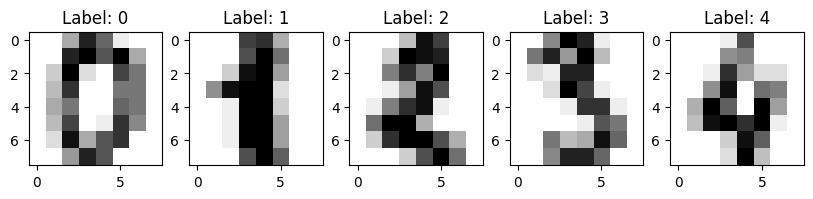

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Data
digits = load_digits()

X = digits.data   # Features (Pixel intensities)
y = digits.target # Labels (0-9)

print(f"Image Data Shape: {X.shape}") # (1797 images, 64 pixels each)
print(f"Labels Shape:     {y.shape}")

# 2. Visualize First 5 Digits
plt.figure(figsize=(10, 4))
for index, (image, label) in enumerate(zip(digits.images[:5], digits.target[:5])):
    plt.subplot(1, 5, index + 1)
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'Label: {label}')
plt.show()

In [2]:
# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale Data (StandardScaler)
# KNN calculates distance; unscaled data distorts these distances.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")

Data scaled successfully.


K=1: Accuracy = 0.9778
K=3: Accuracy = 0.9694
K=5: Accuracy = 0.9750
K=7: Accuracy = 0.9722
K=9: Accuracy = 0.9722
K=11: Accuracy = 0.9722


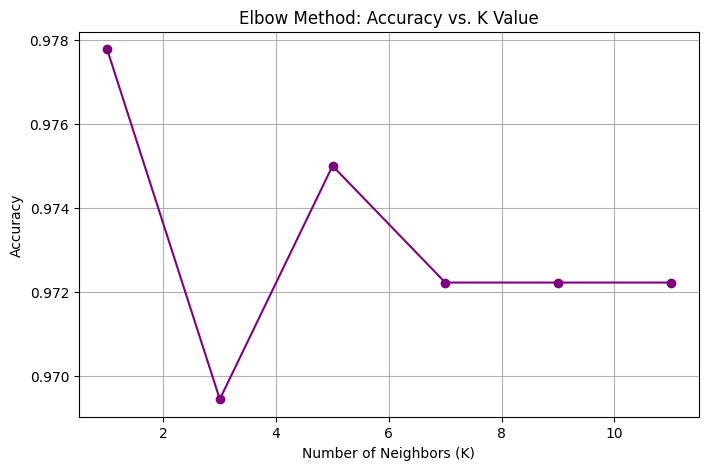


Optimal K selected: 1


In [3]:
# 5 & 6. Train with multiple K values
k_values = [1, 3, 5, 7, 9, 11]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    accuracies.append(score)
    print(f"K={k}: Accuracy = {score:.4f}")

# 7. Plot Accuracy vs K
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='purple')
plt.title('Elbow Method: Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Select best K (Let's stick with the highest one, usually K=5 or 7 is robust)
best_k = k_values[np.argmax(accuracies)]
print(f"\nOptimal K selected: {best_k}")

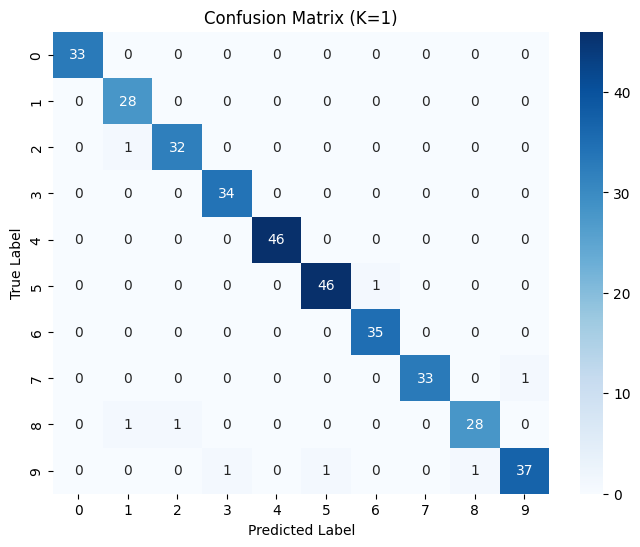


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       0.97      0.97      0.97        33
           3       0.97      1.00      0.99        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       0.97      0.93      0.95        30
           9       0.97      0.93      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [4]:
# 8. Final Model Evaluation
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (K={best_k})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

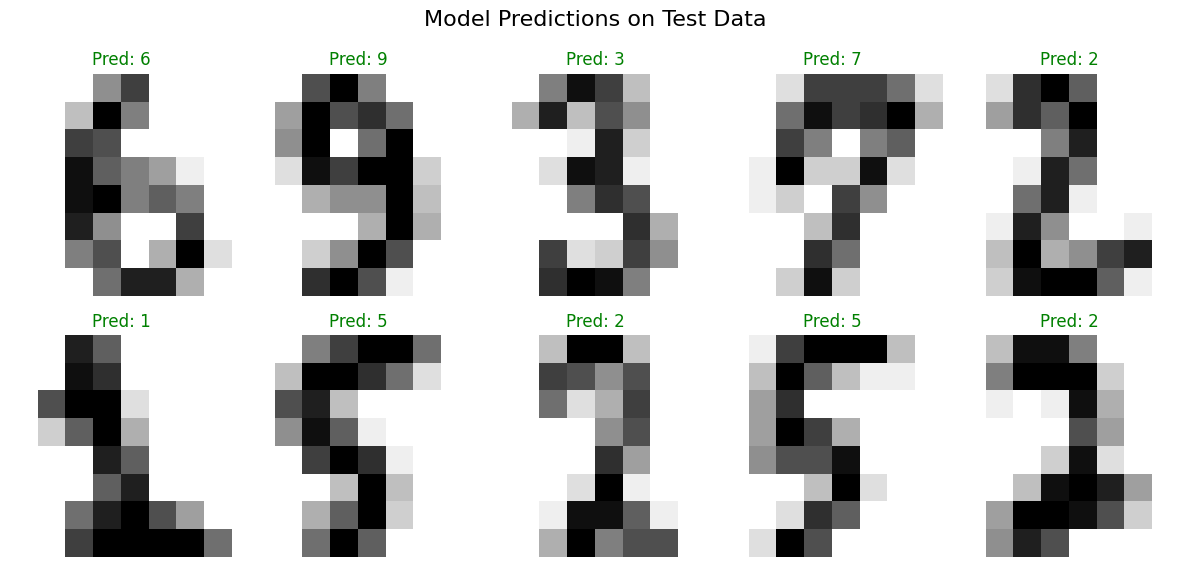

In [5]:
# 9. Display Sample Predictions
# We need to reshape the flat X_test back into 8x8 images to plot them
X_test_images = X_test.reshape(-1, 8, 8)

plt.figure(figsize=(12, 6))
for i in range(10): # Show first 10 test images
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_images[i], cmap=plt.cm.gray_r, interpolation='nearest')

    # Color logic: Green if correct, Red if wrong
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"Pred: {y_pred[i]}", color=color)
    plt.axis('off')

plt.suptitle("Model Predictions on Test Data", fontsize=16)
plt.tight_layout()
plt.show()

## 🧠 Evaluation & Conclusion

### 1. The Best K
We plotted Accuracy vs. K. Typically, **K=3, 5, or 7** performs best.
* **Low K (e.g., 1):** Overfits. The decision boundary is too jagged, reacting to noise.
* **High K:** Underfits. The boundary becomes too smooth and ignores local patterns.

### 2. Confusion Matrix Analysis
The confusion matrix shows where the model struggled.
* Common confusion: The model might confuse a sloppy **'8'** with a **'3'**, or a **'9'** with a **'5'**.
* Overall, KNN is highly effective for this dataset, often achieving **97%+ accuracy**.

### 3. Takeaway
We successfully built an image classifier without using Deep Learning! KNN is powerful for simple pattern recognition tasks where data points (images) with similar pixels cluster together in mathematical space.